# ERI integral evaluation: some tests
This notebook will serve as a brief playground to compare and test the three integral codes: PySCF, Oatmeal and Interest, in order to define an appropriate wrapper for Interest (and maybe Oatmeal at some point), to obtain the full ERI-ao tensor. As always, we will start with the imports:

In [1]:
from typing import List, Tuple

import numpy as np
from numpy.typing import NDArray
from numpy.ctypeslib import ndpointer

import ctypes as ct

from pyscf import gto

from py_mods.src.integrals.GTO import GTO, create_GTO
from py_mods.src.integrals.CGTO import Eri_GTO_tensor


---

# Same angular momenta shells
## PySCF: the reference
We will be using PySCF as a reference, as all the internal code can yield the ERI-AO tensor directly, while the other codes at this point only yield shell-based ERI-AO tensors. We will start by building the ERI-AO references of same angular momenta $s$, $p$ or $d$ basis composed of a single primitive:

In [2]:
l_tags = ["S", "P", "D", "F", "G", "H"]
reference_eri_tensors = []


def ssn(T):
    T = np.array(T, dtype=float, copy=True)
    out = np.zeros_like(T)

    pos = T > 0
    neg = T < 0

    if np.any(pos):
        out[pos] = T[pos] / np.max(T[pos])

    if np.any(neg):
        out[neg] = T[neg] / abs(np.min(T[neg]))

    return out


for l in range(0, 4):
    mol = gto.M(
        atom="H -.2 0 0; He .4 .5 .6",
        unit="Bohr",
        basis={
            "H": gto.basis.parse(
                f"""
            # This is the standard STO-3G definition
            # Exponent    Contraction Coeff
            H {l_tags[l+1]}
            3.0    0.15
            # 1    1
            """
            ),
            "He": gto.basis.parse(
                f"""
            He {l_tags[l+1]}
            3.0    0.35
            # 1    1
            """
          # recall that is exponent, coefficient
            )
        },
        cart=True,
        charge=-1
    )

    mol.build()

    overlap = mol.intor("int1e_ovlp")
    kin = mol.intor("int1e_kin")
    V = mol.intor("int1e_nuc")
    ref_eri = mol.intor("int2e")

    norm_vec = 1.0 / np.sqrt(np.diag(overlap))

    ref_eri *= norm_vec[:, None, None, None]
    ref_eri *= norm_vec[None, :, None, None]
    ref_eri *= norm_vec[None, None, :, None]
    ref_eri *= norm_vec[None, None, None, :]

    reference_eri_tensors.append(np.array(ref_eri))

eri_s_oneatom, eri_p_oneatom, eri_d_oneatom, eri_f_oneatom = reference_eri_tensors

print(f"S tensor shape is: {eri_s_oneatom.shape}")
print(f"P tensor shape is: {eri_p_oneatom.shape}")
print(f"D tensor shape is: {eri_d_oneatom.shape}")
print(f"F tensor shape is: {eri_f_oneatom.shape}")

S tensor shape is: (6, 6, 6, 6)
P tensor shape is: (12, 12, 12, 12)
D tensor shape is: (20, 20, 20, 20)
F tensor shape is: (30, 30, 30, 30)


In [3]:
l_tags = ["S", "P", "D", "F", "G", "H"]
reference_eri_tensors = []

for l in range(0, 4):
    mol = gto.M(
        atom="H 0 0 0; He 0 0 0",
        unit="Bohr",
        basis={
            "H": gto.basis.parse(
                f"""
            # This is the standard STO-3G definition
            # Exponent    Contraction Coeff
            H {l_tags[l]}
            3.0    0.15
            # 1    1
            """
            ),
            "He": gto.basis.parse(
                f"""
            He {l_tags[l+1]}
            3.0    0.35
            # 1    1
            """
          # recall that is exponent, coefficient
            )
        },
        cart=True,
        charge=-1
    )

    mol.build()
    print(mol.ao_labels())

    overlap = mol.intor("int1e_ovlp")
    kin = mol.intor("int1e_kin")
    V = mol.intor("int1e_nuc")
    ref_eri = mol.intor("int2e")

    norm_vec = 1.0 / np.sqrt(np.diag(overlap))

    ref_eri *= norm_vec[:, None, None, None]
    ref_eri *= norm_vec[None, :, None, None]
    ref_eri *= norm_vec[None, None, :, None]
    ref_eri *= norm_vec[None, None, None, :]

    reference_eri_tensors.append(np.array(ref_eri))

eri_sp_oneatom, eri_pd_oneatom, eri_df_oneatom, eri_fg_oneatom = reference_eri_tensors

print(f"S tensor shape is: {eri_sp_oneatom.shape}")
print(f"P tensor shape is: {eri_pd_oneatom.shape}")
print(f"D tensor shape is: {eri_df_oneatom.shape}")
print(f"F tensor shape is: {eri_fg_oneatom.shape}")

['0  H 1s    ', '1 He 2px   ', '1 He 2py   ', '1 He 2pz   ']
['0  H 2px   ', '0  H 2py   ', '0  H 2pz   ', '1 He 3dxx  ', '1 He 3dxy  ', '1 He 3dxz  ', '1 He 3dyy  ', '1 He 3dyz  ', '1 He 3dzz  ']
['0  H 3dxx  ', '0  H 3dxy  ', '0  H 3dxz  ', '0  H 3dyy  ', '0  H 3dyz  ', '0  H 3dzz  ', '1 He 4fxxx ', '1 He 4fxxy ', '1 He 4fxxz ', '1 He 4fxyy ', '1 He 4fxyz ', '1 He 4fxzz ', '1 He 4fyyy ', '1 He 4fyyz ', '1 He 4fyzz ', '1 He 4fzzz ']
['0  H 4fxxx ', '0  H 4fxxy ', '0  H 4fxxz ', '0  H 4fxyy ', '0  H 4fxyz ', '0  H 4fxzz ', '0  H 4fyyy ', '0  H 4fyyz ', '0  H 4fyzz ', '0  H 4fzzz ', '1 He 5gxxxx', '1 He 5gxxxy', '1 He 5gxxxz', '1 He 5gxxyy', '1 He 5gxxyz', '1 He 5gxxzz', '1 He 5gxyyy', '1 He 5gxyyz', '1 He 5gxyzz', '1 He 5gxzzz', '1 He 5gyyyy', '1 He 5gyyyz', '1 He 5gyyzz', '1 He 5gyzzz', '1 He 5gzzzz']
S tensor shape is: (4, 4, 4, 4)
P tensor shape is: (9, 9, 9, 9)
D tensor shape is: (16, 16, 16, 16)
F tensor shape is: (25, 25, 25, 25)


In [4]:
l_tags = ["S", "P", "D", "F", "G", "H"]
reference_eri_tensors = []

for l in range(0, 4):
    mol = gto.M(
        atom="H 0 1.4 0; H 0.7 0 1.4;",
        unit="Bohr",
        basis={
            "H": gto.basis.parse(
                f"""
            # This is the standard STO-3G definition
            # Exponent    Contraction Coeff
            H {l_tags[l]}
            3.0    0.15
            # 1    1
        """  # recall that is exponent, coefficient
            )
        },
        cart=True,
    )

    mol.build()

    overlap = mol.intor("int1e_ovlp")
    kin = mol.intor("int1e_kin")
    V = mol.intor("int1e_nuc")
    ref_eri = mol.intor("int2e")

    norm_vec = 1.0 / np.sqrt(np.diag(overlap))

    ref_eri *= norm_vec[:, None, None, None]
    ref_eri *= norm_vec[None, :, None, None]
    ref_eri *= norm_vec[None, None, :, None]
    ref_eri *= norm_vec[None, None, None, :]

    reference_eri_tensors.append(np.array(ref_eri))

eri_s, eri_p, eri_d, eri_f = reference_eri_tensors

print(f"S tensor shape is: {eri_s.shape}")
print(f"P tensor shape is: {eri_p.shape}")
print(f"D tensor shape is: {eri_d.shape}")
print(f"F tensor shape is: {eri_f.shape}")

S tensor shape is: (2, 2, 2, 2)
P tensor shape is: (6, 6, 6, 6)
D tensor shape is: (12, 12, 12, 12)
F tensor shape is: (20, 20, 20, 20)


And we will define some mixed shells, due to the eventual need of mixed shells 

In [5]:
l_tags = ["S", "P", "D", "F", "G", "H"]
reference_eri_tensors = []

for l in range(0, 3):
    mol = gto.M(
        atom="H 0 0 0; H 0 0 1.4;",
        unit="Bohr",
        basis={
            "H": gto.basis.parse(
                f"""
            # This is the standard STO-3G definition
            # Exponent    Contraction Coeff
            H {l_tags[l]}
            3.0    0.15
            H {l_tags[l+1]}
            3.0    0.15
        """  # recall that is exponent, coefficient
            )
        },
        cart=True,
    )

    mol.build()

    overlap = mol.intor("int1e_ovlp")
    kin = mol.intor("int1e_kin")
    V = mol.intor("int1e_nuc")
    ref_eri = mol.intor("int2e")

    norm_vec = 1.0 / np.sqrt(np.diag(overlap))

    ref_eri *= norm_vec[:, None, None, None]
    ref_eri *= norm_vec[None, :, None, None]
    ref_eri *= norm_vec[None, None, :, None]
    ref_eri *= norm_vec[None, None, None, :]

    reference_eri_tensors.append(np.array(ref_eri))

eri_sp, eri_pd, eri_df = reference_eri_tensors

print(f'SP tensor shape is: {eri_sp.shape}')
print(f'PD tensor shape is: {eri_pd.shape}')
print(f'DF tensor shape is: {eri_df.shape}')

SP tensor shape is: (8, 8, 8, 8)
PD tensor shape is: (18, 18, 18, 18)
DF tensor shape is: (32, 32, 32, 32)



---

## Oatmeal
Now we will try to obtain the same results with the Oatmeal code, but we need a wrapper!! Because at this point we can only obtain the shell tensors:


In [6]:
def naive_wrapper(gto_list: List[GTO]) -> NDArray[np.float64]: 
    projections = [len(primitive.l_projections) for primitive in gto_list]
    shell_start = [sum(projections[0:i]) for i in range(len(projections))]
    tensor_size = (sum(projections))

    # print(f"Number of projections are: {tensor_size}")
    # print(f"Projections per shell are: {projections}")
    # print(shell_start)

    eri_tensor = np.zeros([tensor_size for i in range(4)])
    # print(f'Tensor size is: {eri_tensor.shape}')

    for P, p_gto in enumerate(gto_list):
        p_size = projections[P]
        p_start = shell_start[P]
        p_end = shell_start[P] + p_size
        for Q, q_gto in enumerate(gto_list):
            q_size = projections[Q]
            q_start = shell_start[Q]
            q_end = shell_start[Q] + q_size
            for R, r_gto in enumerate(gto_list):
                r_size = projections[R]
                r_start = shell_start[R]
                r_end = shell_start[R] + r_size
                for S, s_gto in enumerate(gto_list):
                    s_size = projections[S]
                    s_start = shell_start[S]
                    s_end = shell_start[S] + s_size
                    eri_tensor[p_start:p_end, q_start:q_end, r_start:r_end, s_start:s_end] = Eri_GTO_tensor(p_gto, q_gto, r_gto, s_gto)

    return eri_tensor

In [7]:
def single_shell_spd_test(ref_eri_list: List[NDArray]):
    oatmeal_eris = []
    eri_s, eri_p, eri_d = ref_eri_list

    for l in range(0, 3):
        r1 = np.array([0.0, 0.0, 0.0])
        r2 = np.array([0.0, 0.0, 1.4])
        H_exps = 3
        H_coeffs = 0.15

        # Construct the CGTO
        atom_1_basis = create_GTO(r1, H_exps, l)
        atom_2_basis = create_GTO(r2, H_exps, l)

        gto_list = [atom_1_basis, atom_2_basis]

        Eri_test: NDArray[np.float64] = naive_wrapper(gto_list)

        oatmeal_eris.append((Eri_test))

    oat_eri_s, oat_eri_p, oat_eri_d = oatmeal_eris

    print(f"S tensor is equivalent to pyscf's: {np.allclose(oat_eri_s, eri_s)}")
    print(f"P tensor is equivalent to pyscf's: {np.allclose(oat_eri_p, eri_p)}")
    print(f"D tensor is equivalent to pyscf's: {np.allclose(oat_eri_d, eri_d)}")

    return (
        np.allclose(oat_eri_s, eri_s)
        and np.allclose(oat_eri_p, eri_p)
        and np.allclose(oat_eri_d, eri_d)
    )

In [8]:
def mixed_shell_sp_test(mixed_eri_list):
    oatmeal_eris = []

    for l in range(0, 2):
        r1 = np.array([0.0, 0.0, 0.0])
        r2 = np.array([0.0, 0.0, 1.4])
        H_exps = 3
        H_coeffs = 0.15

        # Construct the CGTO
        atom_1_basis = create_GTO(r1, H_exps , l)
        atom_2_basis = create_GTO(r2, H_exps , l)
        atom_1_basis_2 = create_GTO(r1, H_exps , l+1)
        atom_2_basis_2 = create_GTO(r2, H_exps, l+1)

        gto_list = [atom_1_basis, atom_1_basis_2, atom_2_basis, atom_2_basis_2]

        Eri_test: NDArray[np.float64] = naive_wrapper(gto_list)



        oatmeal_eris.append((Eri_test))
        print(f"S tensor is equivalent to pyscf's: {np.allclose(mixed_eri_list[l], Eri_test)}")

    oat_eri_sp, oat_eri_pd = oatmeal_eris
    eri_sp, eri_pd = mixed_eri_list



    return np.allclose(oat_eri_sp, eri_sp) and np.allclose(oat_eri_pd, eri_pd)

In [9]:
# print(f'\n\nSingle shell for S, P and D passed: {single_shell_spd_test([eri_s, eri_p, eri_d])}')

eri_list = [eri_sp, eri_pd]

# print(f'\n\nMixed shell for SP passed: {mixed_shell_sp_test(eri_list)}')

Which is cool, but takes $\approx 50$ seconds for just two $d$ primitives. Therefore this is why we need to play with Interest. 

---

## Interest


The Interest interface to C is defined as:

```Fortran
subroutine interest_prim_cls_interface( &
                factor, fint_inp, &
                la_inp, alpha_inp, ax_inp, ay_inp, az_inp, anorm_inp, &
                lb_inp, beta_inp, bx_inp, by_inp, bz_inp, bnorm_inp, &
                lc_inp, gamma_inp, cx_inp, cy_inp, cz_inp, cnorm_inp, &
                ld_inp, delta_inp, dx_inp, dy_inp, dz_inp, dnorm_inp) &
    bind(C, name="interest_prim_py")

    use iso_c_binding, only: c_int, c_double
    use module_interest_eri
    implicit none

    character(len=4) :: class
    real(c_double), value, intent(in) :: factor
    real(c_double), intent(inout) :: fint_inp(1000)

    integer(c_int), value, intent(in) :: la_inp, lb_inp, lc_inp, ld_inp
    real(c_double), value, intent(in) :: alpha_inp, ax_inp, ay_inp, az_inp, anorm_inp
    real(c_double), value, intent(in) :: beta_inp,  bx_inp, by_inp, bz_inp, bnorm_inp
    real(c_double), value, intent(in) :: gamma_inp, cx_inp, cy_inp, cz_inp, cnorm_inp
    real(c_double), value, intent(in) :: delta_inp, dx_inp, dy_inp, dz_inp, dnorm_inp


    call interest_initialize( .false. ) 

    class = 'llll'
    fint_inp = 0.0d0

    call interest_eri(class,factor,fint_inp, &
        la_inp,alpha_inp,ax_inp,ay_inp,az_inp,anorm_inp, &
        lb_inp,beta_inp, bx_inp,by_inp,bz_inp,bnorm_inp, &
        lc_inp,gamma_inp,cx_inp,cy_inp,cz_inp,cnorm_inp, &
        ld_inp,delta_inp,dx_inp,dy_inp,dz_inp,dnorm_inp)

end subroutine interest_prim_cls_interface
```

And once compiled can be called as:

In [10]:
lib = ct.CDLL("/Users/fernando.mata/bin/Oatmeal/notebooks/interest_interface/interest/src/inter_py_lib.so")

lib.interest_prim_py.argtypes = [
    ct.c_double,                                                # factor
    ndpointer(dtype=np.float64, ndim=1, shape=(10000,), flags="C_CONTIGUOUS"),         # fint_inp

    ct.c_int,                                                   # la_inp
    ct.c_double, ct.c_double, ct.c_double, ct.c_double, ct.c_double,

    ct.c_int,                                                   # lb_inp
    ct.c_double, ct.c_double, ct.c_double, ct.c_double, ct.c_double,

    ct.c_int,                                                   # lc_inp
    ct.c_double, ct.c_double, ct.c_double, ct.c_double, ct.c_double,

    ct.c_int,                                                   # ld_inp
    ct.c_double, ct.c_double, ct.c_double, ct.c_double, ct.c_double,
]
lib.interest_prim_py.restype = None

fint = np.zeros(10000, dtype=np.float64)
Na_buffer = np.zeros([10000])

def interest_from_gto(
    gto1: GTO, gto2: GTO, gto3: GTO, gto4: GTO, working_array
) -> None:
    fact =  1

    la = gto1.total_L + 1
    lb = gto2.total_L + 1
    lc = gto3.total_L + 1
    ld = gto4.total_L + 1

    ax, ay, az = gto1.R
    bx, by, bz = gto2.R
    cx, cy, cz = gto3.R
    dx, dy, dz = gto4.R

    a_exp = gto1.exp 
    b_exp = gto2.exp 
    c_exp = gto3.exp 
    d_exp = gto4.exp 

    lib.interest_prim_py(
        fact, working_array,
        la, a_exp, ax, ay, az, 1,
        lb, b_exp, bx, by, bz, 1,
        lc, c_exp, cx, cy, cz, 1,
        ld, d_exp, dx, dy, dz, 1,
    )


---

Since we dont want to pass directly the normalization coefficients, what will be done is to build the normalization tensor as a contraction of the normalization constants such as each element of the tensor has a ijkl normalization constant corresponding to the product of all projections involved. By then doing an elementwise multiplication, all entries shouls be normalized. 

In [11]:
def naive_wrapper_interest(gto_list: List[GTO], buffer_1) -> NDArray[np.float64]:
    projections = [len(primitive.l_projections) for primitive in gto_list]
    shell_start = [sum(projections[0:i]) for i in range(len(projections))]
    tensor_size = sum(projections)

    eri_tensor = np.zeros([tensor_size for _ in range(4)])

    # We chose this lkji order just because DIRAC's code does it too. To be fair I am not
    # sure I understand the need for this ordering. Also, The internal transpositions on
    # Interest.
    for L, L_gto in enumerate(gto_list):  # l
        L_size, L_start, L_end, L_consts = unpack_primitive(projections, shell_start, L, L_gto)

        for K, K_gto in enumerate(gto_list):  # k
            K_size, K_start, K_end, K_consts = unpack_primitive(projections, shell_start, K, K_gto)

            for J, J_gto in enumerate(gto_list):  # j
                J_size, J_start, J_end, J_consts = unpack_primitive(projections, shell_start, J, J_gto)
                
                for I, I_gto in enumerate(gto_list):  # i
                    I_size, I_start, I_end, I_consts = unpack_primitive(projections, shell_start, I, I_gto)

                    shell_total_size = I_size * J_size * K_size * L_size
                    buffer_1[:shell_total_size] = 0.0

                    interest_from_gto(K_gto, L_gto, I_gto, J_gto, buffer_1)

                    tmp = buffer_1[:shell_total_size].reshape(
                        (L_size, K_size, J_size, I_size)
                    )

                    # So since what we have built is eri[K,L,I,J], we need to transpose to get IJKL
                    block = tmp.transpose(3, 2, 1, 0)

                    # And now that we are on IJKL, we just operate all normally with this indexing.
                    # We contract the normalization
                    norm_tensor = np.einsum(
                        "i,j,k,l->ijkl", I_consts, J_consts, K_consts, L_consts
                    )
                    block *= norm_tensor

                    # And fill the block
                    eri_tensor[
                        I_start:I_end, J_start:J_end, K_start:K_end, L_start:L_end
                    ] = block

    eri = eri_tensor
    return eri


def unpack_primitive(projections, shell_start, index, gto):
    L_size = projections[index]
    L_start = shell_start[index]
    L_end = shell_start[index] + L_size
    L_consts = gto.normalization_constants
    return L_size, L_start, L_end, L_consts


---


And the Whole method as an importable function:

In [12]:
from py_mods.src.integrals.external.interest.interest import interest_full_tensor as naive_wrapper_interest

In [13]:
oatmeal_eris = []
for l in range(0, 1):
    r1 = np.array([-0.2, 0.0, 0.0])
    r2 = np.array([0.4, 0.5, 0.6])
    H_exps = 3
    H_coeffs = 0.15

    # Construct the CGTO
    atom_1_basis = create_GTO(r1, H_exps, l + 2)
    atom_2_basis = create_GTO(r2, H_exps, l + 2)

    gto_list = [atom_1_basis, atom_2_basis]
    # gto_list = [atom_1_basis, atom_2_basis]

    Eri_test: NDArray[np.float64] = naive_wrapper_interest(gto_list)

    oatmeal_eris.append((Eri_test))

oat_eri_p = oatmeal_eris[0]

print(oat_eri_p.shape)
print(eri_p_oneatom.shape)

from py_mods.src.SCF.plot_utilities import plot_map

all_true = True

reference = eri_p_oneatom

for i in range(0, 1):
    for j in range(0, 12):
        tmpmat = np.zeros_like(oat_eri_p[0, 0, :, :], dtype=np.complex128)
        tmpmat.real = oat_eri_p[i, j, :, :]
        tmpmat.imag = reference[i, j, :, :]  # - oat_eri_p[i,j,:,:]

        sliceisequal = np.allclose(
            oat_eri_p[i, j, :, :], reference[i, j, :, :], rtol=2e-14
        )

        # plot_map(tmpmat, title=f'Case: [{i}, {j}, :, :], Equal: {sliceisequal}')
        print(
            f"f'Case: [{i}, {j}, :, :], Equal: {sliceisequal}. Pyscf is symmetric: {np.allclose(reference[i,j,:,:], reference[i,j,:,:].T)}. We are symmetric: {np.allclose(oat_eri_p[i,j,:,:], oat_eri_p[i,j,:,:].T)}"
        )  # , but if we permute to [{j}, :, {i}, :], Equal: {np.allclose(oat_eri_p[:,:,i,j], eri_p[i,j,:,:])}")

        if not sliceisequal:
            plot_map(tmpmat, title=f"Case: [{i}, {j}, :, :], Equal: {sliceisequal}")
            all_true = False

if all_true:
    print("All ERIs are aligned")

# oat_eri_p

(12, 12, 12, 12)
(12, 12, 12, 12)
f'Case: [0, 0, :, :], Equal: True. Pyscf is symmetric: True. We are symmetric: True
f'Case: [0, 1, :, :], Equal: True. Pyscf is symmetric: True. We are symmetric: True
f'Case: [0, 2, :, :], Equal: True. Pyscf is symmetric: True. We are symmetric: True
f'Case: [0, 3, :, :], Equal: True. Pyscf is symmetric: True. We are symmetric: True
f'Case: [0, 4, :, :], Equal: True. Pyscf is symmetric: True. We are symmetric: True
f'Case: [0, 5, :, :], Equal: True. Pyscf is symmetric: True. We are symmetric: True
f'Case: [0, 6, :, :], Equal: True. Pyscf is symmetric: True. We are symmetric: True
f'Case: [0, 7, :, :], Equal: True. Pyscf is symmetric: True. We are symmetric: True
f'Case: [0, 8, :, :], Equal: True. Pyscf is symmetric: True. We are symmetric: True
f'Case: [0, 9, :, :], Equal: True. Pyscf is symmetric: True. We are symmetric: True
f'Case: [0, 10, :, :], Equal: True. Pyscf is symmetric: True. We are symmetric: True
f'Case: [0, 11, :, :], Equal: True. Pyscf

--------------

In [14]:
'''
    mol = gto.M(
        atom="H -.2 0 0; He .4 .5 .6",
        unit="Bohr",
        basis={
            "H": gto.basis.parse(
                f"""
            # This is the standard STO-3G definition
            # Exponent    Contraction Coeff
            H {l_tags[l]}
            3.0    0.15
            # 1    1
            """
            ),
            "He": gto.basis.parse(
                f"""
            He {l_tags[l+1]}
            3.0    0.35
            # 1    1
            """
          # recall that is exponent, coefficient
            )
        },
'''

oatmeal_eris = []
for l in range(0, 1):
    r1 = np.array([0, 0.0, 0.0])
    r2 = np.array([0, 0, 0])
    H_exp = 3
    H_coeffs = 0.15

    # Construct the CGTO
    atom_1_basis = create_GTO(r1, H_exp, l+2)
    atom_2_basis = create_GTO(r2, H_exp, l+3)

    gto_list = [atom_1_basis, atom_2_basis] 
    # gto_list = [atom_1_basis, atom_2_basis]

    Eri_test: NDArray[np.float64] = naive_wrapper_interest(gto_list, fint)
    

    oatmeal_eris.append((Eri_test))

oat_eri_p = oatmeal_eris[0]

print(oat_eri_p.shape)
print(eri_df_oneatom.shape)

all_true = True 

reference = eri_df_oneatom

for i in range(0,9):
    for j in range(0,9):
        tmpmat = np.zeros_like(oat_eri_p[0,0,:,:], dtype=np.complex128)
        tmpmat.real = oat_eri_p[:,:,i,j]
        tmpmat.imag = reference[:,:,i,j]  # - oat_eri_p[:,:,i,j]

        sliceisequal = np.allclose(oat_eri_p[:,:,i,j], reference[:,:,i,j], rtol=2E-14)

        # plot_map(tmpmat, title=f'Case: [{i}, {j}, :, :], Equal: {sliceisequal}')
        # print(f"f'Case: [:,:,{i}, {j}], Equal: {sliceisequal}. Pyscf is symmetric: {np.allclose(reference[:,:,i,j], reference[:,:,i,j].T)}. We are symmetric: {np.allclose(oat_eri_p[:,:,i,j], oat_eri_p[:,:,i,j].T)}") # , but if we permute to [{j}, :, {i}, :], Equal: {np.allclose(oat_eri_p[:,:,i,j], eri_p[i,j,:,:])}")
        if not sliceisequal:
            plot_map(tmpmat, title=f'Case: [{i}, {j}, :, :], Equal: {sliceisequal}. Pyscf is symmetric: {np.allclose(reference[i,j,:,:], reference[i,j,:,:].T)}. We are symmetric: {np.allclose(oat_eri_p[i,j,:,:], oat_eri_p[i,j,:,:].T)}')

            all_true = False

if all_true:
    print('All ERIs are aligned')

# oat_eri_p

(16, 16, 16, 16)
(16, 16, 16, 16)
All ERIs are aligned


In [15]:
def interest_mixed_shell_sp_test(eri_list, buffer_1):
    oatmeal_eris = []

    for l in range(0, 3):
        r1 = np.array([0.0, 0.0, 0.0])
        r2 = np.array([0.0, 0.0, 1.4])
        H_exps = 3
        H_coeffs = 0.15

        # Construct the CGTO
        atom_1_basis = create_GTO(r1, H_exps,  l)
        atom_2_basis = create_GTO(r2, H_exps,  l)
        atom_1_basis_2 = create_GTO(r1, H_exps,  l+1)
        atom_2_basis_2 = create_GTO(r2, H_exps,  l+1)

        gto_list = [atom_1_basis, atom_1_basis_2, atom_2_basis, atom_2_basis_2]

        Eri_test: NDArray[np.float64] = naive_wrapper_interest(gto_list, buffer_1=buffer_1)

        oatmeal_eris.append((Eri_test))

    # print(repr(oatmeal_eris))

    oat_eri_sp, oat_eri_pd, oat_eri_df = oatmeal_eris
    eri_sp, eri_pd, eri_df = eri_list
    print(f"S tensor is equivalent to pyscf's: {np.allclose(oat_eri_sp, eri_sp)}")
    print(f"P tensor is equivalent to pyscf's: {np.allclose(oat_eri_pd, eri_pd)}")
    print(f"D tensor is equivalent to pyscf's: {np.allclose(oat_eri_df, eri_df)}")

    return np.allclose(oat_eri_sp, eri_sp) and np.allclose(oat_eri_pd, eri_pd) and np.allclose(oat_eri_df, eri_df)

In [16]:
interest_mixed_shell_sp_test([eri_sp, eri_pd, eri_df], fint)

S tensor is equivalent to pyscf's: True
P tensor is equivalent to pyscf's: True
D tensor is equivalent to pyscf's: True


True


---

Now only two basis pairs have been tested, so we need to check more generalized cases:

In [19]:
mol = gto.M(
    atom="H 0 0 0; H 0 0 1.4; H -.2 .4 0; H .3 .6 -.9",
    unit="Bohr",
    basis={
        "H": gto.basis.parse(
            f"""
        # This is the standard STO-3G definition
        # Exponent    Contraction Coeff
        H {l_tags[0]}
        1.0    0.05
        H {l_tags[1]}
        2.0    0.15
        H {l_tags[2]}
        3.0    0.25
    """  # recall that is exponent, coefficient
        )
    },
    cart=True,
)

mol.build()

overlap = mol.intor("int1e_ovlp")
kin = mol.intor("int1e_kin")
V = mol.intor("int1e_nuc")
ref_eri = mol.intor("int2e")

norm_vec = 1.0 / np.sqrt(np.diag(overlap))

ref_eri *= norm_vec[:, None, None, None]
ref_eri *= norm_vec[None, :, None, None]
ref_eri *= norm_vec[None, None, :, None]
ref_eri *= norm_vec[None, None, None, :]


In [ ]:
r1 = np.array([0.0, 0.0, 0.0])
r2 = np.array([0.0, 0.0, 1.4])
r3 = np.array([-0.2, 0.4, 0])
r4 = np.array([0.3, 0.6, -0.9])
H_exps = [1, 2, 3]

# Construct the CGTO
a1s = create_GTO(r1, 1, 0)
a1p = create_GTO(r1, 2, 1)
a1d = create_GTO(r1, 3, 2)

a2s = create_GTO(r2, 1, 0)
a2p = create_GTO(r2, 2, 1)
a2d = create_GTO(r2, 3, 2)

a3s = create_GTO(r3, 1, 0)
a3p = create_GTO(r3, 2, 1)
a3d = create_GTO(r3, 3, 2)

a4s = create_GTO(r4, 1, 0)
a4p = create_GTO(r4, 2, 1)
a4d = create_GTO(r4, 3, 2)

gto_list = [a1s, a1p, a1d, a2s, a2p, a2d, a3s, a3p, a3d, a4s, a4p, a4d]

Eri_test: NDArray[np.float64] = naive_wrapper_interest(
    gto_list,
)

In [21]:
np.allclose(Eri_test, ref_eri)

True

With this we can see that pyscf tensors are built by atom, by l:

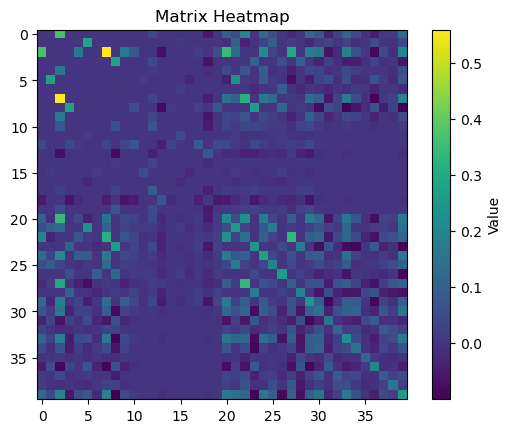

In [26]:
plot_map(Eri_test[2,7,:,:])